## Indexes using Quantum Circuits and their performance


In [1]:
import qiskit
#from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
from collections import Counter
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import random
import time
from itertools import combinations
#from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city


## Step 1: Generating our data

In [89]:
# We will simulate some functions in the form of S->O , S->P etc. 
# We will generate n amount of bitstrings and match it with random bitstrings within 2^bits
# 


# Amount of bits to describe data
bits = 7


#dataAmount = 10**4
dataAmount = 2**bits

filename = "bitstringPairs.txt"
print(f"\n I will create a file with : {dataAmount:.4f} pairs")


# Edited function taken from SuperpositionMeasuringTime.ipynb by Yannis Tzitzikas
def write_ordered_pairs(n_lines, n_bits, filename):
    max_possible = 2**n_bits
    if n_lines > max_possible:
        raise ValueError(f"Cannot generate {n_lines} unique {n_bits}-bit strings. Max is {max_possible}.")

    # Generate ordered bitstrings
    #pairs =  [f"{format(i, f'0{n_bits}b')} {format(random.randint(0, n_lines-1), f'0{n_bits}b')}" for i in range(0, n_lines)]
    pairs = [f"{format(i, f'0{n_bits}b')} {random.randint(0,1)}" for i in range(n_lines)]

    # Write to file
    with open(filename, 'w') as f:
        for p in pairs:
            f.write(p + '\n')

    # Print the output
    print(f"\n✅ {n_lines} ordered {n_bits}-bit strings written to '{filename}':\n")
   # for i, b in enumerate(bitstrings, start=1):
   #     print(f"Line {i}: {b} ({len(b)} bits)")

    print(f"\n📊 Total lines written: {len(pairs)}")

# Measure file creation time time
start_time = time.time()
# This will generated dataAmount pairs of different inputs to 1 output each simulating a function
write_ordered_pairs(dataAmount,bits,filename)
end_time = time.time()

# Display elapsed time
elapsed = end_time - start_time
print(f"\n⏱️ Execution time: {elapsed:.4f} seconds")





 I will create a file with : 128.0000 pairs

✅ 128 ordered 7-bit strings written to 'bitstringPairs.txt':


📊 Total lines written: 128

⏱️ Execution time: 0.0014 seconds


## Step 2: Generating the input for the circuit algorithm

In [90]:
# Now we will prepare the input for the Younes-Miller algorithm
# We need to collect in a list, each input (ex. 101101) that makes the selected bit of output 1 (ex 101011<- for the first bit)
# We also need to organize them into lists and tuples to match the expected input of the algorithm implementation

start_time = time.time()

#datasets/rows/loading time/preparing input/create circuit/Gates/ Depth/ Output



inputs = [[] for _ in range(bits)]

# Reading the pairs from the file
with open(filename, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Loading time: {elapsed:.4f} seconds")
start_time = time.time()

# For each different input in our file, we will add it in the nth output bit list only if that bit is 1
for line in lines:
    inputBitstring, outputBitstring = line.split()
    inputTuple = tuple(int(bit) for bit in inputBitstring)

    for i,bit in enumerate(outputBitstring):
        if bit == '1':
            inputs[i].append(inputTuple)

end_time = time.time()

# Display elapsed time
elapsed = end_time - start_time
print(f"\n⏱️ Preparing input time: {elapsed:.4f} seconds")





⏱️ Loading time: 0.0084 seconds

⏱️ Preparing input time: 0.0007 seconds


## Step 3: Running the Younes-Miller Algorithm

In [91]:


gates = 0


def minimizeAndGenerate(outputCounter,all0): # Function to minimize the number of AND gates and add them to the circuit
    visited = [] # List to store unique control combinations
    unique = []
    global gates

    counter = Counter(tuple(c) for c in controlsArray) 
    unique = [list(k) for k, v in counter.items() if v % 2 != 0] #Keeping only the gates that appear odd number of times since the even ones cancel out

    for u in unique:
        controls = [a[j] for j in range(inputSize) if u[j] == 1] # Getting the control qubits from the unique combinations
        if len(controls)!=0:
            qc.mcx(controls, b[outputCounter]) # Adding the controls to the circuit
            gates += 1
    if all0 == 1:
        qc.x(b[outputCounter]) # Adding the NOT gate if required
        gates += 1
    qc.measure(b[outputCounter], outputCounter) # Measuring the output
    controlsArray.clear() # Resetting the controls array for the next input
    unique.clear() # Resetting the unique list for the next input


start_time = time.time()
inputSize = bits
outputSize = 1
conf = inputs
gates = 0

a = QuantumRegister(inputSize, 'a')
b = QuantumRegister(outputSize, 'b')
qc = QuantumCircuit(a, b)
c = ClassicalRegister(outputSize, 'output_b0')
qc.add_register(c)

all0 = 0 
cond0 = []
controlsArray = []
outputCounter = 0


for c in conf:
    for input in c:
        cond0= []
        tmp = 0
        for i in range(inputSize):
            if input[i] == 0:
                cond0.insert(0,i)   # Storing the cond0 qubits
            else:
                tmp = 1
        if(tmp==0):
            all0 = 1                        
        for i in range(0, len(cond0)+1):
                for combo in combinations(cond0, i):
                    column = [1] * len(input)                   # Initializing a column with all 1s
                    for j in combo:
                        column[j] = 0                   # Setting the cond0 qubits to 0
                    controlsArray.append(column)                # Appending the column to the controls array
    
    minimizeAndGenerate(outputCounter,all0) # Calling the minimizer function that will also add the gates to the circuit
    all0 = 0 # Resetting the all 0 flag for the next input set
    if(outputSize > 1): 
        outputCounter += 1


end_time = time.time()

# Display elapsed time
elapsed = end_time - start_time
print(f"\n⏱️ Execution time: {elapsed:.4f} seconds")
print(f"\n Gates needed: {gates}")
print(f"\n Circuit depth: {qc.depth()}")

#qc.draw(output='mpl')  



⏱️ Execution time: 0.0088 seconds

 Gates needed: 72

 Circuit depth: 79


In [75]:


gates = 0



start_time = time.time()
inputSize = bits
outputSize = bits
conf = inputs
gates = 0
outputCounter = 0
a = QuantumRegister(inputSize, 'a')
b = QuantumRegister(outputSize, 'b')
qc = QuantumCircuit(a, b)
c = ClassicalRegister(outputSize, 'output_b0')
qc.add_register(c)

for c in conf:
    for input in c:
        for i in range(inputSize):
            if input[i] == 0:
                qc.x(a[i]) ## Setting the qubit to cond-0

        qc.mcx(a,b[outputCounter]) ## Linking all control qubits to target b0

        for i in range(inputSize): 
            if input[i] == 0:
                qc.x(a[i]) ## Resetting the qubits to original state
    qc.measure(b[outputCounter], outputCounter)
    outputCounter += 1

end_time = time.time()

# Display elapsed time
elapsed = end_time - start_time
print(f"\n⏱️ Execution time: {elapsed:.4f} seconds")
print(f"\n Gates needed: {gates}")
print(f"\n Circuit depth: {qc.depth()}")

#qc.draw(output='mpl')  



⏱️ Execution time: 0.0029 seconds

 Gates needed: 0

 Circuit depth: 41


## Step 4: Measuring counts

In [19]:
qc.measure_all()
# Transpile for simulator
simulator = AerSimulator()
start_time = time.time()
qc = transpile(qc, simulator)
end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Transpile of the quantum circuit: {elapsed:.4f} seconds")


⏱️ Transpile of the quantum circuit: 0.2977 seconds


In [ ]:
# Run and get counts
start_time = time.time()
simulator =AerSimulator()
result = simulator.run(qc,shots=1).result()
end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Simulator time: {elapsed:.4f} seconds")

counts = result.get_counts()
print("Counts:", counts)
plot_histogram(counts, title='Αποτελέσματα')

In [55]:



qc.measure_all()

SUPPORTED_MCX = {
    "x", "cx", "ccx", "mcx", "mcx_gray", "mcx_recursive", "mcx_vchain"
}

def run_classically_io(qc: QuantumCircuit, inputs, outputs, return_counts=False):
    if len(qc.qregs) != 2:
        raise ValueError(
            f"Expected 2 quantum registers (inputs/outputs), got {len(qc.qregs)}."
        )

    qin, qout = qc.qregs
    n_in, n_out = len(qin), len(qout)

    if len(inputs) != n_in or len(outputs) != n_out:
        raise ValueError(
            f"Input/output lengths must match register sizes "
            f"({n_in} / {n_out}), got ({len(inputs)} / {len(outputs)})."
        )

    # 
    bits = inputs + outputs
    qindex = {q: i for i, q in enumerate(qc.qubits)}
    creg_values = {} 

    # --- simulate -------------------------------------------------------------
    for instr in qc.data:
        op = instr.operation
        name = op.name

        # Skip barriers and delays
        if name in {"barrier", "id", "delay"}:
            continue

        # Measurement handling
        if name == "measure":
            q = instr.qubits[0]
            c = instr.clbits[0]
            creg_values[c] = bits[qindex[q]]
            continue

        # Logic gates
        if name not in SUPPORTED_MCX:
            raise ValueError(f"Unsupported gate: {name}")

        qubits = [qindex[q] for q in instr.qubits]

        if name == "x":
            bits[qubits[0]] ^= 1
        else:
            controls, target = qubits[:-1], qubits[-1]
            if all(bits[c] for c in controls):
                bits[target] ^= 1

    # --- split and optional counts --------------------------------------------
    final_inputs = bits[:n_in]
    final_outputs = bits[n_in:]

    if return_counts:
        bitstring = ''.join(str(b) for b in reversed(final_outputs))
        return (final_inputs, final_outputs), {bitstring: 1}
    else:
        return final_inputs, final_outputs


#0000010111  

inputs  = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
outputs = [0]*17

start_time = time.time()




final_inputs, final_outputs = run_classically_io(qc, inputs, outputs)

print("Final inputs :", final_inputs)
print("Final outputs:", final_outputs)
end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Output of the quantum circuit: {elapsed:.4f} seconds")



Final inputs : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Final outputs: [0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]

⏱️ Output of the quantum circuit: 32.6360 seconds


## Testing on IBM


qiskit_runtime_service.__init__:WARNING:2026-03-04 19:59:17,011: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QuaC. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-04 19:59:21,205: Loading instance: QuaC, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-04 19:59:26,654: Using instance: QuaC, plan: open


Using backend: ibm_fez
Transpilation time:  1.7203857898712158
Original depth: 79
Hardware depth: 10961
Hardware qubits: 156
Job ID: d6k761860irc7395dl2g

Counts:


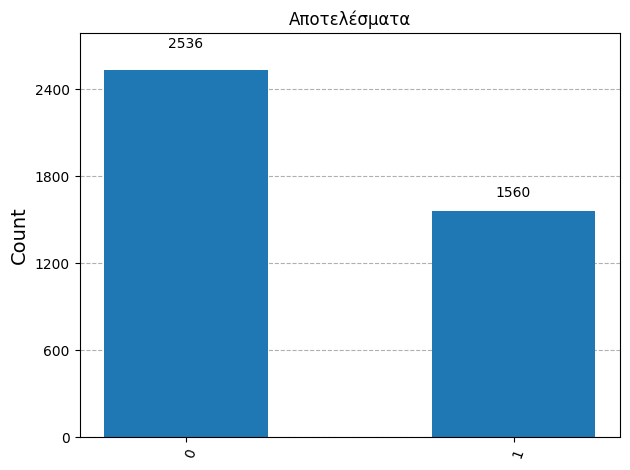

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Options
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="", #Insert your API key here
    overwrite=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

backend = service.least_busy(simulator=False, operational=True)

# backend = service.backend("ibm_brisbane")

print("Using backend:", backend.name)

#Transpile for the chosen backend
start_time = time.time()
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=3)
qc_hw = pass_manager.run(qc)
end_time = time.time()

elapsed_time = end_time - start_time
print("Transpilation time: ", elapsed_time)
print("Original depth:", qc.depth())
print("Hardware depth:", qc_hw.depth())
print("Hardware qubits:", backend.num_qubits)

#Run on hardware
shots = 4096
sampler = SamplerV2(backend)
job = sampler.run([qc_hw], shots=shots)
print("Job ID:", job.job_id())

result = job.result()

# Get counts
pub = result[0]

creg_name = qc.cregs[0].name
bitarr = getattr(pub.data, creg_name)   # BitArray
counts = bitarr.get_counts()

print("\nCounts:")
plot_histogram(counts, title='Αποτελέσματα')

Testing Grover on IBM

C:\Users\Gexie\AppData\Local\Temp\ipykernel_16812\852499860.py:51: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover_op = GroverOperator(oracle)


Bits of each marked state 4
Number of  marked states 1
Optimal number of iterations: 3

⏱️ Execution time of the Grover operator: 0.0014 seconds

⏱️ Execution time (for transpilation): 0.0844 seconds
Original depth: 5
Hardware depth: 437


qiskit_runtime_service.__init__:WARNING:2026-03-04 20:15:39,427: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QuaC. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-04 20:15:42,156: Loading instance: QuaC, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-04 20:15:48,301: Using instance: QuaC, plan: open


Using backend: ibm_fez
Number of shots 4096

⏱️ Execution time: 21.2895 seconds


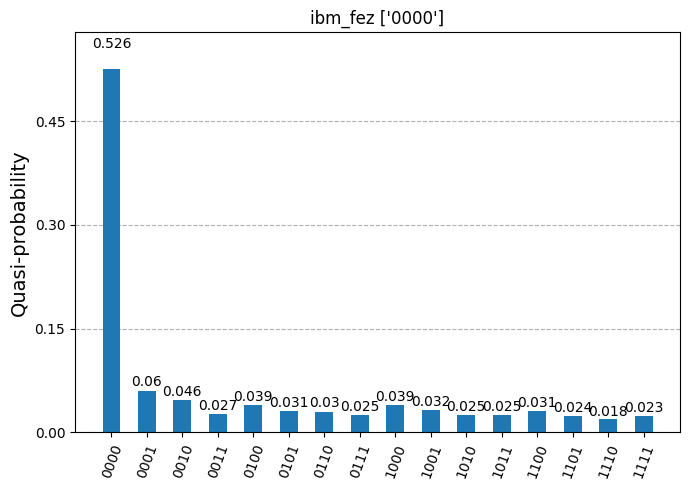

In [ ]:
# Built-in modules
import math
import time

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution

# Imports from Qiskit Aer
from qiskit_aer import AerSimulator

# Imports from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2
from qiskit_ibm_runtime import SamplerV2 as Sampler

def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Here we assume all input marked states have the same number of bits

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])  # the number of qbits is determined by the bit length of each state

    qc_ga = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bit-string to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bit-string
        zero_inds = [ind for ind in range(num_qubits) if rev_target.startswith("0", ind)]
        # Add a multi-controlled Z-gate with pre- and post-applied X-gates (open-controls)
        # where the target bit-string has a '0' entry
        qc_ga.x(zero_inds)   # ...
        qc_ga.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)  # ...
        qc_ga.x(zero_inds)  # ...
    return qc_ga

marked_states = ["0000"]
oracle = grover_oracle(marked_states)  # calls the function defined earlier with input the marked stated

grover_op = GroverOperator(oracle)
grover_op.decompose().draw(output="mpl", style="iqp")

print("Bits of each marked state", len(marked_states[0]))
print("Number of  marked states", len(marked_states))


optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)
optimal_num_iterations

print("Optimal number of iterations:",  optimal_num_iterations)


qc_ga = QuantumCircuit(grover_op.num_qubits)
# Create even superposition of all basis states
qc_ga.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
start_time = time.time()
qc_ga.compose(grover_op.power(optimal_num_iterations), inplace=True)
end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Execution time of the Grover operator: {elapsed:.4f} seconds")
# Measure all qubits
qc_ga.measure_all()
#qc.draw(output="mpl", style="iqp")

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
start_time = time.time()

pm = generate_preset_pass_manager(target=target, optimization_level=3)

circuit_isa = pm.run(qc_ga)

end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Execution time (for transpilation): {elapsed:.4f} seconds")
print("Original depth:", qc_ga.depth())
print("Hardware depth:", circuit_isa.depth())

service = QiskitRuntimeService(channel="ibm_quantum_platform")


backend = service.least_busy(simulator=False, operational=True)

# backend = service.backend("ibm_brisbane")

print("Using backend:", backend.name)
#circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")

# To run on local simulator:

sampler = Sampler(mode=backend)
#sampler.options.default_shots = 10_000
sampler.options.default_shots = 4096

start_time = time.time()
result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

end_time = time.time()
elapsed = end_time - start_time
print("Number of shots", sampler.options.default_shots) 
print(f"\n⏱️ Execution time: {elapsed:.4f} seconds")

plot_distribution(dist, title=f"{backend.name} {marked_states}")